# Stage 2. Additive LoRA, rank sweep
### CB1 (six-class) | Gemma-2-9B-it | W = W + AB

Sweeps the adapter rank over r in {4, 8, 16, 32} and selects the rank on the **validation**
partition. The test set is evaluated once, for the selected configuration only.

**Reported in:** Sec. 4.3 of the paper, and the S2 column of Table 3.

**Protocol.** 75/25 stratified split at seed 42, a further 10% of train held out for validation,
near-duplicate removal at TF-IDF cosine 0.90, four-bit NF4 quantization, one epoch, batch 4.
Macro F1 is the primary metric and MCC the secondary.

**Result.** Validation selects r = 32, giving a test Macro F1 of 0.9035 with 35,804,160
trainable parameters.

**How to run.** Run Step 1, restart the runtime, then run the remaining steps in order.

In [13]:
# ── Environment and protocol notes ────────────────────────────────────────────
# Three pins changed. Reasons:
#   datasets<4.0.0   : datasets 4.0 imports VideoReader from torchvision.io, which
#                      no longer exists in torchvision 0.26. Crashes at training time.
#   transformers cap : 4.52+ changes the Trainer eval signature this notebook relies on.
#   no torchvision / numpy / pandas pins: the old ones no longer resolve on Python 3.13
#                      and pip aborts the WHOLE command when one pin fails.
# RESTART THE RUNTIME after this cell, then run from the next cell onwards.
# ─────────────────────────────────────────────────────────────────────────────
!pip install -q -U \
    "transformers>=4.47.0,<4.52.0" \
    "accelerate>=0.33.0" \
    "bitsandbytes>=0.43.0" \
    "peft>=0.11.1" \
    "datasets>=3.0.0,<4.0.0" \
    scikit-learn \
    matplotlib \
    seaborn

import importlib.metadata as md
for p in ['torch','transformers','peft','bitsandbytes','accelerate','datasets','numpy','pandas']:
    try:    print(f'  {p:16s} {md.version(p)}')
    except Exception: print(f'  {p:16s} NOT INSTALLED')
print()
print('>> NOW: Runtime -> Restart session. Then run from the NEXT cell. Do NOT re-run this one.')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 121.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 160.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 118.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.24.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
  torch            2.11.0+cu128
  transformers     4.51.3
  peft            

---
## Step 2: Import Libraries and Initial Setup

**HF Token required**: `google/gemma-2-9b-it` is gated. Add `HF_TOKEN` to Colab Secrets
(key icon in the left sidebar) before running this cell.

In [1]:
# guard against the datasets/torchvision VideoReader clash ────────
# Belt and braces. The pin above should be enough, but if Colab silently upgrades
# datasets this stops the import from reaching torchvision.io at all.
try:
    import datasets, datasets.config
    datasets.config.TORCHVISION_AVAILABLE = False
except Exception as _e:
    print('torchvision guard skipped:', _e)
# ─────────────────────────────────────────────────────────────────────────────
import os
import random
import collections
import re
from typing import Dict, List

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    balanced_accuracy_score, matthews_corrcoef,
)
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    BitsAndBytesConfig, TrainingArguments, Trainer, TrainerCallback,
)
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
from peft.tuners.lora import LoraLayer
from google.colab import drive, userdata

# ── Reproducibility ──────────────────────────────────────────────────────────
def set_all_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✓ All random seeds fixed to {seed}.")

set_all_seeds(42)

# ── HuggingFace token (required for gated Gemma-2) ───────────────────────────
def load_hf_token() -> str:
    token = userdata.get('HF_TOKEN')
    if token is None:
        raise ValueError("HF_TOKEN not found. Add it via Colab Secrets (key icon in sidebar).")
    os.environ['HF_TOKEN'] = token
    print("✓ HuggingFace token loaded.")
    return token

HF_TOKEN = load_hf_token()

# ── Mount Google Drive ────────────────────────────────────────────────────────
drive.mount('/content/drive')
print("✓ Google Drive mounted.")

# ── GPU check ─────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✓ All random seeds fixed to 42.
✓ HuggingFace token loaded.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted.
✓ Device: cuda
  GPU: NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB


---
## Step 3: Global Configuration

**Gemma-2-9B specific decisions**:
- `TRAIN_BATCH_SIZE = 4` — 9B is ~1.3× larger than Mistral-7B; batch halved to prevent OOM.
- `EVAL_BATCH_SIZE = 8` — reduced accordingly.
- `LEARNING_RATE = 5e-5` — conservative for 9B scale; Mistral at 1e-4 showed high loss CV.
- `token=HF_TOKEN` passed to `from_pretrained` — gated model requires authentication.

In [2]:
# ════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════

MODEL_NAME   = "google/gemma-2-9b-it"
NUM_LABELS   = 6
MAX_LENGTH   = 256

LORA_RANK    = 16
LORA_ALPHA   = 16
LORA_DROPOUT = 0.05
TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj']
RANK_SWEEP   = [4, 8, 16, 32]

NUM_EPOCHS          = 1
LEARNING_RATE       = 5e-5   # conservative for 9B — 1e-4 caused high CV in Mistral-7B
TRAIN_BATCH_SIZE    = 4      # halved vs Mistral — 9B is ~1.3× larger
EVAL_BATCH_SIZE     = 8
WEIGHT_DECAY        = 0.01
EVAL_STEPS          = 200
LOGGING_STEPS       = 50
OUTPUT_DIR          = "/content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B"

CB1_PATH             = "/content/drive/MyDrive/Datasets/cb1.csv"
TRAIN_RATIO          = 0.75
TEST_RATIO           = 0.25
VAL_FROM_TRAIN       = 0.10
SIMILARITY_THRESHOLD = 0.90
RANDOM_STATE         = 42

LABEL_MAPPING = {
    'not_cyberbullying':   0,
    'gender':              1,
    'religion':            2,
    'ethnicity':           3,
    'age':                 4,
    'other_cyberbullying': 5,
}
ID2LABEL     = {v: k for k, v in LABEL_MAPPING.items()}
TARGET_NAMES = list(LABEL_MAPPING.keys())

print("✓ Configuration loaded.")
print(f"  Model      : {MODEL_NAME}")
print(f"  LoRA rank  : {LORA_RANK}  |  alpha: {LORA_ALPHA}  |  scaling: {LORA_ALPHA/LORA_RANK:.1f}")
print(f"  Epochs     : {NUM_EPOCHS}")
print(f"  Batch size : {TRAIN_BATCH_SIZE} train / {EVAL_BATCH_SIZE} eval  (reduced for 9B)")
print(f"  LR         : {LEARNING_RATE}  (conservative for 9B scale)")
print(f"  Split      : {int(TRAIN_RATIO*100)}% train+val / {int(TEST_RATIO*100)}% test  (protocol: 75/25)")
print(f"  Labels ({NUM_LABELS}) : {TARGET_NAMES}")

✓ Configuration loaded.
  Model      : google/gemma-2-9b-it
  LoRA rank  : 16  |  alpha: 16  |  scaling: 1.0
  Epochs     : 1
  Batch size : 4 train / 8 eval  (reduced for 9B)
  LR         : 5e-05  (conservative for 9B scale)
  Split      : 75% train+val / 25% test  (protocol: 75/25)
  Labels (6) : ['not_cyberbullying', 'gender', 'religion', 'ethnicity', 'age', 'other_cyberbullying']


---
## Step 4: Text Preprocessing

In [3]:
def preprocess_text_for_llm(text: str,
                             remove_hashtags: bool = False,
                             remove_emojis: bool = False) -> str:
    if not isinstance(text, str):
        return ""
    text = re.sub(r'\bRT\s+@\w+:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'http\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'@\w+', '[USER]', text)
    if remove_hashtags:
        text = re.sub(r'#(\w+)', r'\1', text)
    if remove_emojis:
        text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'([!?.])\1+', r'\1', text)
    if len(text.split()) < 3:
        return ""
    return text

test_tweet = "RT @user123: Check this out http://example.com !!! @someone is so dumb"
print("Before:", test_tweet)
print("After: ", preprocess_text_for_llm(test_tweet))
print("\n✓ Preprocessing function defined.")

Before: RT @user123: Check this out http://example.com !!! @someone is so dumb
After:  Check this out [URL] ! [USER] is so dumb

✓ Preprocessing function defined.


---
## Step 5: Load and Clean the CB1 Dataset

In [4]:
print("═" * 60)
print("CB1 DATASET LOADING & CLEANING")
print("═" * 60)

df = pd.read_csv(CB1_PATH)
print(f"\n[1] Raw dataset loaded: {len(df):,} samples")

df = df.rename(columns={'tweet_text': 'text', 'cyberbullying_type': 'label'})

corrupt_mask = df['text'].astype(str).str.strip().isin(
    ['#NAME?', '#REF!', '#VALUE!', '#N/A', 'nan', ''])
n_corrupt = corrupt_mask.sum()
df = df[~corrupt_mask].reset_index(drop=True)
print(f"[2] Removed {n_corrupt} corrupt rows → {len(df):,} remaining")

df['text'] = df['text'].apply(preprocess_text_for_llm)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"[3] After preprocessing: {len(df):,} remaining")

text_label_counts = df.groupby('text')['label'].nunique()
conflicting_texts = text_label_counts[text_label_counts > 1].index
n_conflicting     = df['text'].isin(conflicting_texts).sum()
df = df[~df['text'].isin(conflicting_texts)].reset_index(drop=True)
print(f"[4] Removed {n_conflicting:,} annotation-conflict rows → {len(df):,} remaining")

before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f"[5] Removed {before - len(df):,} exact duplicates → {len(df):,} remaining")

before = len(df)
df = df[df['text'].str.split().str.len() >= 3].reset_index(drop=True)
print(f"[6] Removed {before - len(df):,} short texts → {len(df):,} remaining")

unknown_labels = set(df['label'].unique()) - set(LABEL_MAPPING.keys())
assert len(unknown_labels) == 0, f"Unknown labels: {unknown_labels}"

print("\n" + "═" * 60)
print("FINAL CB1 CLASS DISTRIBUTION")
print("═" * 60)
counts = df['label'].value_counts()
for label, count in counts.items():
    print(f"  {label:<25} {count:>6}  ({count/len(df)*100:.1f}%)")
print(f"  {'TOTAL':<25} {len(df):>6}")
imbalance = counts.max() / counts.min()
print(f"\n  Imbalance ratio : {imbalance:.2f}×  → no downsampling needed")
print("  Primary metric  : Macro F1  |  Secondary: MCC")

════════════════════════════════════════════════════════════
CB1 DATASET LOADING & CLEANING
════════════════════════════════════════════════════════════

[1] Raw dataset loaded: 47,692 samples
[2] Removed 0 corrupt rows → 47,692 remaining
[3] After preprocessing: 46,942 remaining
[4] Removed 3,250 annotation-conflict rows → 43,692 remaining
[5] Removed 358 exact duplicates → 43,334 remaining
[6] Removed 0 short texts → 43,334 remaining

════════════════════════════════════════════════════════════
FINAL CB1 CLASS DISTRIBUTION
════════════════════════════════════════════════════════════
  religion                    7979  (18.4%)
  age                         7972  (18.4%)
  ethnicity                   7920  (18.3%)
  gender                      7509  (17.3%)
  not_cyberbullying           6130  (14.1%)
  other_cyberbullying         5824  (13.4%)
  TOTAL                      43334

  Imbalance ratio : 1.37×  → no downsampling needed
  Primary metric  : Macro F1  |  Secondary: MCC


---
## Step 6: Stratified 75/25 Split with Near-Duplicate Check

In [5]:
print("═" * 60)
print("DATASET SPLITTING — Protocol: 75% train / 25% test")
print("═" * 60)

train_val_df, test_df = train_test_split(
    df, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=df['label'])
print(f"\n[1] Primary split → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")

print(f"\n[2] Near-duplicate check (threshold: {SIMILARITY_THRESHOLD})...")
all_texts    = list(train_val_df['text'].values) + list(test_df['text'].values)
vectorizer   = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(all_texts)
train_vecs   = tfidf_matrix[:len(train_val_df)]
test_vecs    = tfidf_matrix[len(train_val_df):]

leaked_indices = []
for start in range(0, len(test_df), 500):
    end         = min(start + 500, len(test_df))
    batch_sims  = cosine_similarity(test_vecs[start:end], train_vecs)
    max_sims    = batch_sims.max(axis=1)
    leaked_mask = max_sims >= SIMILARITY_THRESHOLD
    leaked_indices.extend(test_df.index[start:end][leaked_mask].tolist())

print(f"    Found {len(leaked_indices)} near-duplicate test samples")
if leaked_indices:
    leaked_samples = test_df.loc[leaked_indices]
    test_df      = test_df.drop(leaked_indices).reset_index(drop=True)
    train_val_df = pd.concat([train_val_df, leaked_samples], ignore_index=True)
    print(f"    Moved to train+val → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")
else:
    train_val_df = train_val_df.reset_index(drop=True)
    test_df      = test_df.reset_index(drop=True)
    print("    ✓ No near-duplicates found.")

overlap = set(train_val_df['text'].tolist()).intersection(set(test_df['text'].tolist()))
assert len(overlap) == 0, f"DATA LEAKAGE: {len(overlap)} overlapping samples!"
print("\n    ✓ Data leakage assertion passed — zero train/test overlap.")

train_df, val_df = train_test_split(
    train_val_df, test_size=VAL_FROM_TRAIN, random_state=RANDOM_STATE,
    stratify=train_val_df['label'])
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"\n[3] Validation carved → Train: {len(train_df):,} | Val: {len(val_df):,}")

print("\n" + "═" * 60)
print("FINAL SPLIT STATISTICS")
print("═" * 60)
for name, split_df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    pct = len(split_df) / len(df) * 100
    print(f"\n{name} ({len(split_df):,} samples, {pct:.1f}% of total):")
    for label, count in split_df['label'].value_counts().sort_index().items():
        print(f"  {label:<25} {count:>5}  ({count/len(split_df)*100:.1f}%)")
print(f"\n  ✓ Protocol check: test = {len(test_df)/len(df)*100:.1f}% (target: 25.0%)")

════════════════════════════════════════════════════════════
DATASET SPLITTING — Protocol: 75% train / 25% test
════════════════════════════════════════════════════════════

[1] Primary split → Train+Val: 32,500 | Test: 10,834

[2] Near-duplicate check (threshold: 0.9)...
    Found 504 near-duplicate test samples
    Moved to train+val → Train+Val: 33,004 | Test: 10,330

    ✓ Data leakage assertion passed — zero train/test overlap.

[3] Validation carved → Train: 29,703 | Val: 3,301

════════════════════════════════════════════════════════════
FINAL SPLIT STATISTICS
════════════════════════════════════════════════════════════

Train (29,703 samples, 68.5% of total):
  age                        5420  (18.2%)
  ethnicity                  5497  (18.5%)
  gender                     5149  (17.3%)
  not_cyberbullying          4235  (14.3%)
  other_cyberbullying        3995  (13.4%)
  religion                   5407  (18.2%)

Validation (3,301 samples, 7.6% of total):
  age                 

---
## Step 7: Helper Functions — Class Weights

In [6]:
def get_class_weights(df: pd.DataFrame, label_col: str = 'label') -> List[float]:
    if df.empty:
        return None
    df_mapped = df.copy()
    if df_mapped[label_col].dtype == object:
        df_mapped[label_col] = df_mapped[label_col].map(LABEL_MAPPING)
    class_counts = df_mapped[label_col].value_counts().sort_index()
    N = class_counts.sum(); C = len(class_counts)
    weights = N / (C * class_counts.values)
    weights = weights / weights.sum()
    return weights.tolist()

train_class_weights = get_class_weights(train_df)
print("Class weights (inverse frequency, normalised):")
for label_name, w in zip(TARGET_NAMES, train_class_weights):
    print(f"  {label_name:<25}  weight = {w:.4f}")
print("\n✓ Class weights computed.")

Class weights (inverse frequency, normalised):
  not_cyberbullying          weight = 0.1917
  gender                     weight = 0.1576
  religion                   weight = 0.1501
  ethnicity                  weight = 0.1477
  age                        weight = 0.1498
  other_cyberbullying        weight = 0.2032

✓ Class weights computed.


---
## Step 8: Effective Rank Computation — CORRECTED (4-bit QLoRA Compatible)

SVD on **Wf = W + ΔW** (Fix Bug 1). Uses `bitsandbytes.functional.dequantize_4bit()`
to reconstruct W from NF4 quantised storage.

In [7]:
def calculate_effective_rank(model: nn.Module,
                              threshold_ratio: float = 1e-3) -> Dict[str, float]:
    try:
        import bitsandbytes.functional as bnb_F
        BNB_AVAILABLE = True
    except ImportError:
        BNB_AVAILABLE = False

    full_ranks = []; delta_ranks = []; per_layer = []; skipped = 0

    for name, module in model.named_modules():
        if not isinstance(module, LoraLayer):
            continue
        try:
            A = module.lora_A.default.weight.data
            B = module.lora_B.default.weight.data
            scaling = module.scaling
            if isinstance(scaling, dict):
                scaling = scaling.get('default', 1.0)
            delta_W = (B @ A * scaling).float()

            S_delta = torch.linalg.svdvals(delta_W)
            r_delta = int((S_delta > threshold_ratio * S_delta[0]).sum()) if S_delta[0] > 0 else 0
            delta_ranks.append(r_delta)

            base_layer = module.base_layer
            if not hasattr(base_layer, 'weight'):
                skipped += 1; continue
            weight_obj = base_layer.weight

            if hasattr(weight_obj, 'quant_state') and BNB_AVAILABLE:
                try:
                    W = bnb_F.dequantize_4bit(weight_obj.data, weight_obj.quant_state).float()
                except Exception:
                    skipped += 1; continue
            else:
                W = weight_obj.data.float()

            if W.shape != delta_W.shape:
                if W.T.shape == delta_W.shape:
                    W = W.T.contiguous()
                else:
                    skipped += 1; continue

            Wf   = W + delta_W
            S_Wf = torch.linalg.svdvals(Wf)
            r_full = int((S_Wf > threshold_ratio * S_Wf[0]).sum()) if S_Wf[0] > 0 else 0
            full_ranks.append(r_full)
            per_layer.append({'layer': name, 'rank_Wf': r_full, 'rank_deltaW': r_delta})
        except Exception:
            skipped += 1; continue

    if skipped > 0:
        print(f"  ℹ {skipped} LoRA layers skipped")

    return {
        "avg_effective_rank_Wf":     float(np.mean(full_ranks))  if full_ranks  else 0.0,
        "avg_effective_rank_deltaW": float(np.mean(delta_ranks)) if delta_ranks else 0.0,
        "lora_layer_count":          len(full_ranks),
        "per_layer_ranks":           per_layer,
    }

print("✓ calculate_effective_rank() — 4-bit QLoRA compatible.")
print("  → SVD on Wf = W + ΔW  (theoretically meaningful)")
print("  → ΔW rank tracked as reference  (trivially ≤ r)")

✓ calculate_effective_rank() — 4-bit QLoRA compatible.
  → SVD on Wf = W + ΔW  (theoretically meaningful)
  → ΔW rank tracked as reference  (trivially ≤ r)


---
## Step 9: Evaluation Metrics

In [8]:
def compute_metrics(eval_pred) -> Dict[str, float]:
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=1)
    accuracy  = accuracy_score(labels, predictions)
    _, _, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0)
    mcc = matthews_corrcoef(labels, predictions)
    return {"accuracy": accuracy, "f1": f1, "mcc": mcc}


def evaluate_dataset(y_true: List[int], y_pred: List[int],
                     dataset_name: str) -> Dict[str, float]:
    print(f"\n{'═'*65}")
    print(f"FINAL EVALUATION — {dataset_name}")
    print(f"{'═'*65}")
    accuracy     = accuracy_score(y_true, y_pred)
    macro_f1     = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    weighted_f1  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    bal_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc          = matthews_corrcoef(y_true, y_pred)
    print(f"  Accuracy          : {accuracy:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}  ← PRIMARY METRIC")
    print(f"  Weighted F1       : {weighted_f1:.4f}")
    print(f"  Balanced Accuracy : {bal_accuracy:.4f}")
    print(f"  MCC               : {mcc:.4f}  ← SECONDARY METRIC")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, labels=list(range(NUM_LABELS)),
                                 target_names=TARGET_NAMES, zero_division=0, digits=4))
    cm      = confusion_matrix(y_true, y_pred, labels=list(range(NUM_LABELS)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    axes[0].set_title(f'Confusion Matrix (Counts)\n{dataset_name}', fontsize=12)
    axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')
    axes[0].tick_params(axis='x', rotation=45)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, vmin=0, vmax=1)
    axes[1].set_title(f'Confusion Matrix (Normalised — Recall)\n{dataset_name}', fontsize=12)
    axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_{dataset_name.replace(' ','_')}.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    return {'accuracy': accuracy, 'macro_f1': macro_f1,
            'weighted_f1': weighted_f1, 'balanced_accuracy': bal_accuracy, 'mcc': mcc}


def make_predictions(model, df_test, tokenizer, batch_size=16):
    model.eval()
    sentences  = df_test['text'].tolist()
    all_logits = []
    dev        = next(model.parameters()).device
    with torch.no_grad():
        for start in range(0, len(sentences), batch_size):
            batch   = sentences[start:start + batch_size]
            inputs  = tokenizer(batch, return_tensors="pt",
                                padding=True, truncation=True, max_length=MAX_LENGTH)
            inputs  = {k: v.to(dev) for k, v in inputs.items()}
            outputs = model(**inputs)
            all_logits.append(outputs.logits.cpu())
    all_logits         = torch.cat(all_logits, dim=0)
    df_test            = df_test.copy()
    df_test['predictions'] = all_logits.argmax(dim=1).numpy()
    return df_test

print("✓ Metric functions defined.")

✓ Metric functions defined.


---
## Step 10: Training Stability System

Two dimensions tracked (single-epoch protocol):
- **Loss Stability**: std dev & CV of training loss across steps
- **Metric Stability**: std dev of val F1 & MCC across eval checkpoints

Panels 3 & 4 (Gradient Norm Per Epoch / Per-Epoch Loss Stability) intentionally omitted.

In [9]:
class StabilityCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []
        self.val_metrics  = collections.defaultdict(list)
        self.val_steps    = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or state.global_step == 0: return
        if 'loss' in logs:
            self.train_losses.append((state.global_step, float(logs['loss'])))

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics: return
        self.val_steps.append(state.global_step)
        for key, value in metrics.items():
            self.val_metrics[key.replace('eval_', '')].append(float(value))

    def get_stability_report(self) -> Dict:
        report = {}
        if self.train_losses:
            arr = np.array([l for (_, l) in self.train_losses])
            report['loss_mean_overall'] = float(np.mean(arr))
            report['loss_std_overall']  = float(np.std(arr))
            report['loss_cv_overall']   = float(np.std(arr)/np.mean(arr)) if np.mean(arr)>0 else 0.0
        for metric, values in self.val_metrics.items():
            if len(values) > 1:
                arr = np.array(values)
                report[f'val_{metric}_std']   = float(np.std(arr))
                report[f'val_{metric}_range'] = float(arr.max()-arr.min())
                report[f'val_{metric}_best']  = float(arr.max())
                report[f'val_{metric}_final'] = float(arr[-1])
        loss_cv = report.get('loss_cv_overall', 0.0)
        f1_std  = report.get('val_f1_std', 0.0)
        report['stability_score'] = round((loss_cv * 0.5) + (f1_std * 0.5), 6)
        return report

    def plot_stability_curves(self, stage_label: str = 'Stage 2', save_path: str = None):
        """2-panel stability figure (single-epoch protocol)."""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        if self.train_losses:
            steps  = [s for (s, _) in self.train_losses]
            losses = [l for (_, l) in self.train_losses]
            ax1.plot(steps, losses, color='steelblue', linewidth=0.7,
                     alpha=0.5, label='Step loss')
            window = min(20, len(losses))
            if len(losses) >= window:
                roll = np.convolve(losses, np.ones(window)/window, mode='valid')
                ax1.plot(steps[window-1:], roll, color='navy', linewidth=2.2,
                         label=f'Rolling mean (w={window})')
            ax1.set_title(f'{stage_label}\nTraining Loss Curve', fontsize=12)
            ax1.set_xlabel('Global Step'); ax1.set_ylabel('Cross-Entropy Loss')
            ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
        else:
            ax1.text(0.5, 0.5, 'No training loss data.', ha='center', va='center',
                     transform=ax1.transAxes, fontsize=10, color='grey')
            ax1.set_title(f'{stage_label}\nTraining Loss Curve', fontsize=12)

        if self.val_steps:
            ax2_r = ax2.twinx() if 'mcc' in self.val_metrics else None
            if 'f1' in self.val_metrics:
                f1_vals = self.val_metrics['f1']
                ax2.plot(self.val_steps, f1_vals, 'o-', color='forestgreen',
                         linewidth=2, markersize=5, label='Macro F1')
                f1_mean = float(np.mean(f1_vals)); f1_std = float(np.std(f1_vals))
                ax2.axhline(f1_mean, color='forestgreen', linestyle=':', linewidth=1.2, alpha=0.6)
                ax2.fill_between(self.val_steps,
                                  [f1_mean-f1_std]*len(self.val_steps),
                                  [f1_mean+f1_std]*len(self.val_steps),
                                  color='forestgreen', alpha=0.10,
                                  label=f'±1 std (={f1_std:.4f})')
                ax2.set_ylabel('Macro F1', color='forestgreen', fontsize=10)
                ax2.tick_params(axis='y', labelcolor='forestgreen')
            if ax2_r is not None and 'mcc' in self.val_metrics:
                ax2_r.plot(self.val_steps, self.val_metrics['mcc'], 's--',
                           color='darkorange', linewidth=2, markersize=5, label='MCC')
                ax2_r.set_ylabel('MCC', color='darkorange', fontsize=10)
                ax2_r.tick_params(axis='y', labelcolor='darkorange')
                lines1, lbl1 = ax2.get_legend_handles_labels()
                lines2, lbl2 = ax2_r.get_legend_handles_labels()
                ax2.legend(lines1+lines2, lbl1+lbl2, fontsize=9, loc='lower right')
            ax2.set_title(f'{stage_label}\nValidation Metrics Across Checkpoints', fontsize=12)
            ax2.set_xlabel('Global Step'); ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, 'No validation data.', ha='center', va='center',
                     transform=ax2.transAxes, fontsize=10, color='grey')
            ax2.set_title(f'{stage_label}\nValidation Metrics Across Checkpoints', fontsize=12)

        plt.suptitle(f'Training Stability Analysis — {stage_label}',
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f'  ✓ Stability plot saved → {save_path}')
        plt.show()


class CustomTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = (
            torch.tensor(class_weights, dtype=torch.float32).to(self.args.device)
            if class_weights is not None else None)

    def compute_loss(self, model, inputs, num_items_in_batch=None, return_outputs=False):
        labels  = inputs.pop('labels').long()
        outputs = model(**inputs)
        loss    = nn.functional.cross_entropy(outputs.logits, labels, weight=self.class_weights)
        return (loss, outputs) if return_outputs else loss


def plot_cross_stage_stability(stage_reports: Dict[str, Dict], save_path: str = None):
    labels  = list(stage_reports.keys())
    n       = len(labels)
    colours = ['#2E75B6', '#2E86AB', '#1B998B', '#F4A261'][:n]
    metrics_map = {
        'Loss Std Dev\n(Overall)':              'loss_std_overall',
        'Loss CV\n(Coeff. of Variation)':       'loss_cv_overall',
        'Val F1 Std Dev\n(Across Checkpoints)': 'val_f1_std',
        'Composite\nStability Score':           'stability_score',
    }
    fig, axes = plt.subplots(1, len(metrics_map), figsize=(5.5*len(metrics_map), 6))
    for ax, (metric_label, metric_key) in zip(axes, metrics_map.items()):
        values = [stage_reports[lbl].get(metric_key, 0.0) or 0.0 for lbl in labels]
        bars   = ax.bar(range(n), values, color=colours, alpha=0.85,
                        edgecolor='white', linewidth=1.5, width=0.6)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(values+[1e-9])*0.03,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_xticks(range(n)); ax.set_xticklabels(labels, fontsize=9)
        ax.set_title(metric_label, fontsize=11, fontweight='bold')
        ax.set_ylabel('Value  (lower = more stable)', fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        if metric_key == 'stability_score':
            ax.axhspan(0, 0.05, alpha=0.08, color='green', label='Very stable')
            ax.axhspan(0.05, 0.15, alpha=0.08, color='orange', label='Acceptable')
            ax.axhspan(0.15, max(values+[0.2])*1.2, alpha=0.08, color='red', label='Unstable')
            ax.legend(fontsize=8, loc='upper left')
    plt.suptitle(
        'Cross-Stage Training Stability Comparison\n'
        'CB1 — 6-Class Cyberbullying | google/gemma-2-9b-it',
        fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  ✓ Cross-stage stability plot saved → {save_path}')
    plt.show()

print('✓ StabilityCallback (2-dimension, single-epoch protocol) defined.')
print('  [Panels 3 & 4 removed — uninformative with 1 epoch]')
print('✓ CustomTrainer defined.')
print('✓ plot_cross_stage_stability() defined.')

✓ StabilityCallback (2-dimension, single-epoch protocol) defined.
  [Panels 3 & 4 removed — uninformative with 1 epoch]
✓ CustomTrainer defined.
✓ plot_cross_stage_stability() defined.


---
## Step 11: Standard LoRA Training Function

**Gemma-2-9B specific**:
- `token=HF_TOKEN` passed to `from_pretrained` — gated model requires authentication
- `TRAIN_BATCH_SIZE = 4` — halved vs Mistral to accommodate 9B model on A100 40GB
- `LEARNING_RATE = 5e-5` — conservative; reduces risk of the high loss CV seen in Mistral-7B
- `bf16=True` — bfloat16 compute (Gemma-2 protocol from Stage 1)
- **Padding token**: Gemma tokenizer has no default pad token; set to `eos_token`

In [10]:
def run_standard_lora(
    train_df:  pd.DataFrame,
    val_df:    pd.DataFrame,
    test_df:   pd.DataFrame,
    lora_rank: int,
    run_label: str = ''
) -> Dict:
    """Train and evaluate Standard (Additive) LoRA on CB1. Formula: Wf = W + AB"""
    set_all_seeds(RANDOM_STATE)
    lora_alpha = lora_rank
    label      = run_label or f'StandardLoRA_r{lora_rank}'

    print(f'\n{"="*65}')
    print(f'  STAGE 2 — STANDARD LoRA  |  {label}')
    print(f'  Model   : {MODEL_NAME}')
    print(f'  Rank r  : {lora_rank}  |  Alpha: {lora_alpha}  |  Scaling: {lora_alpha/lora_rank:.1f}')
    print(f'  Formula : Wf = W + AB')
    print(f'  Epochs  : {NUM_EPOCHS}  (single-epoch protocol)')
    print(f'{"="*65}')

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    run_dir = os.path.join(OUTPUT_DIR, label)
    os.makedirs(run_dir, exist_ok=True)

    # ── 1. Tokenizer ──────────────────────────────────────────────────────────
    print('\n[1] Loading tokenizer...')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)
    # Gemma has no default pad token — set to eos_token
    if tokenizer.pad_token is None:
        tokenizer.pad_token    = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id
    print(f'   Vocab size: {tokenizer.vocab_size:,}')
    print(f'   Pad token : "{tokenizer.pad_token}" (id={tokenizer.pad_token_id})')

    def tokenise(examples):
        return tokenizer(examples['text'],
                         padding='max_length', truncation=True, max_length=MAX_LENGTH)

    # ── 2. Labels and datasets ────────────────────────────────────────────────
    print('[2] Mapping labels and preparing datasets...')
    train_m = train_df.copy(); val_m = val_df.copy(); test_m = test_df.copy()
    for split in [train_m, val_m, test_m]:
        split['label'] = split['label'].map(LABEL_MAPPING)
        assert split['label'].notnull().all(), 'Unmapped labels detected!'

    hf_train = Dataset.from_pandas(
        train_m[['text','label']].reset_index(drop=True)
    ).map(tokenise, batched=True, remove_columns=['text'])
    hf_val = Dataset.from_pandas(
        val_m[['text','label']].reset_index(drop=True)
    ).map(tokenise, batched=True, remove_columns=['text'])
    hf_train.set_format('torch'); hf_val.set_format('torch')
    print(f'   Train: {len(hf_train):,} | Val: {len(hf_val):,} | Test: {len(test_m):,}')

    # ── 3. Quantisation (4-bit NF4 QLoRA) ────────────────────────────────────
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

    # ── 4. LoRA config ────────────────────────────────────────────────────────
    lora_config = LoraConfig(
        r=lora_rank, lora_alpha=lora_alpha,
        target_modules=TARGET_MODULES,
        lora_dropout=LORA_DROPOUT,
        bias='none', task_type='SEQ_CLS',
    )

    # ── 5. Load model (HF token required for gated Gemma-2) ──────────────────
    print('[3] Loading model (4-bit NF4 QLoRA)...')
    # Note 22 Aug. transformers renamed torch_dtype -> dtype in 4.56.
    # We pin transformers < 4.52, where the kwarg is still torch_dtype.
    # Try the old name first, fall back to the new one. No version strings.
    import transformers as _tf
    _common = dict(quantization_config=quant_config, num_labels=NUM_LABELS,
                   device_map='auto', token=HF_TOKEN)
    try:
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME, torch_dtype=torch.bfloat16, **_common)
        print(f'   transformers {_tf.__version__}, used torch_dtype=')
    except TypeError:
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME, dtype=torch.bfloat16, **_common)
        print(f'   transformers {_tf.__version__}, used dtype=')
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache    = False
    model = prepare_model_for_kbit_training(model)
    model = get_peft_model(model, lora_config)
    trainable, total = model.get_nb_trainable_parameters()
    print(f'   Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.3f}%)')

    # ── 6. Training arguments ─────────────────────────────────────────────────
    training_args = TrainingArguments(
        output_dir=run_dir,
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        eval_strategy='steps',
        eval_steps=EVAL_STEPS,
        logging_strategy='steps',
        logging_steps=LOGGING_STEPS,
        save_strategy='no',
        load_best_model_at_end=False,
        warmup_ratio=0.05,
        lr_scheduler_type='cosine',
        fp16=False,
        bf16=True,
        report_to='none',
        dataloader_pin_memory=False,
    )

    # ── 7. Trainer ────────────────────────────────────────────────────────────
    stability_cb = StabilityCallback()
    trainer = CustomTrainer(
        model=model, args=training_args,
        train_dataset=hf_train, eval_dataset=hf_val,
        compute_metrics=compute_metrics,
        class_weights=get_class_weights(train_m),
        callbacks=[stability_cb],
    )

    # ── 8. Train ──────────────────────────────────────────────────────────────
    print(f'[4] Training — {NUM_EPOCHS} epoch (single-epoch protocol)...')
    trainer.train()

    # ── 9. Effective rank ─────────────────────────────────────────────────────
    print('\n[5] Computing effective rank of Wf = W + AB...')
    rank_metrics = calculate_effective_rank(model)
    print(f'   avg_effective_rank(Wf) = {rank_metrics["avg_effective_rank_Wf"]:.2f}')
    print(f'   avg_effective_rank(ΔW) = {rank_metrics["avg_effective_rank_deltaW"]:.2f}  (reference, ≤ r={lora_rank})')
    print(f'   LoRA layers measured   = {rank_metrics["lora_layer_count"]}')

    # ── 10. Stability ─────────────────────────────────────────────────────────
    print('\n[6] Generating stability report...')
    stability_report = stability_cb.get_stability_report()
    val_best  = stability_report.get('val_f1_best',  float('nan'))
    val_final = stability_report.get('val_f1_final', float('nan'))
    print(f'   VALIDATION Macro F1 - best: {val_best:.4f} | final: {val_final:.4f}'
          f'   <-- RANK SELECTION USES THIS, NOT THE TEST SCORE')
    print(f'   Loss CV (overall)   : {stability_report.get("loss_cv_overall",  "N/A")}')
    print(f'   Loss std (overall)  : {stability_report.get("loss_std_overall", "N/A")}')
    print(f'   Val F1 std          : {stability_report.get("val_f1_std",       "N/A")}')
    print(f'   Val MCC std         : {stability_report.get("val_mcc_std",      "N/A")}')
    print(f'   Composite score     : {stability_report.get("stability_score",  "N/A")}')
    score = stability_report.get('stability_score', None)
    if score is not None:
        if   score < 0.05:  print('   Interpretation      : ✅  Very stable')
        elif score < 0.15:  print('   Interpretation      : 🟡  Acceptable')
        else:               print('   Interpretation      : 🔴  Unstable — investigate')

    stability_cb.plot_stability_curves(
        stage_label=f'Stage 2 — Standard LoRA  (Wf = W + AB, r={lora_rank})',
        save_path=os.path.join(run_dir, 'stability_curves.png'))

    # ── 11. Inference on held-out 25% test set ────────────────────────────────
    print('[7] Running inference on held-out test set (25% of full dataset)...')
    test_with_preds = make_predictions(model, test_m, tokenizer)
    final_metrics = evaluate_dataset(
        y_true=test_with_preds['label'].tolist(),
        y_pred=test_with_preds['predictions'].tolist(),
        dataset_name=f'CB1 Test — {label}')

    # ── 12. Save ──────────────────────────────────────────────────────────────
    results = {
        'run_label': label, 'lora_rank': lora_rank, 'lora_alpha': lora_alpha,
        'trainable_params': trainable,
        **final_metrics,
        'avg_eff_rank_Wf':  rank_metrics['avg_effective_rank_Wf'],
        'avg_eff_rank_dW':  rank_metrics['avg_effective_rank_deltaW'],
        'val_f1_best':      stability_report.get('val_f1_best',  float('nan')),
        'val_f1_final':     stability_report.get('val_f1_final', float('nan')),
        'stability_score':  stability_report.get('stability_score', None),
        'stability_report': stability_report,
        'stability_cb':     stability_cb,
    }
    scalars_path = os.path.join(run_dir, f'results_{label}.csv')
    pd.DataFrame([{k: v for k, v in results.items()
                   if not isinstance(v, (dict, StabilityCallback))}
                 ]).to_csv(scalars_path, index=False)
    print(f'\n✓ Results saved → {scalars_path}')
    del model, trainer
    torch.cuda.empty_cache()
    return results

print('✓ run_standard_lora() fully defined.')

✓ run_standard_lora() fully defined.


---
## Step 12: Execute — Default Run (r = 16)

**Expected performance**: Gemma-2-9B is a well-aligned model. In Stage 1 it achieved
the best zero-shot F1 among all decoders (0.502), suggesting strong general language
understanding. LoRA should unlock significant gains over the ICL baseline.

**Targets to beat**:
- Stage 1 ceiling: Phi-4 FS F1 = 0.5757
- Llama-3.2-3B Stage 2 r=16: F1 = 0.8938
- Mistral-7B Stage 2 r=16:   F1 = 0.8808  ← Gemma-2 expected to exceed this

In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
#  SKIP THIS CELL.
#  It runs r=16 on its own. The sweep cell below covers r = 4, 8, 16, 32 and
#  selects on validation. Running it again adds no information.
# ═════════════════════════════════════════════════════════════════════════════
print('Skipped on purpose. Go to the RANK SWEEP cell below.')


---
## Step 13: Rank Sweep Ablation — r ∈ {4, 8, 16, 32}

**Cross-model pattern to watch**: Llama showed monotonically increasing F1 with rank;
Mistral showed the opposite (decreasing). Gemma-2-9B will reveal whether the inverse
pattern is a 7B-specific quirk or a general property of larger/more-aligned models.

**Runtime**: ~8–10 hours total for 4 runs on A100. Batch size = 4 means more steps
per epoch (~7,426) than Mistral (~3,713). Each run takes approximately 2–2.5 hours.
Consider running ranks individually if session stability is a concern.


------------------------------------------------------------
  Rank sweep: r = 4   (1 of 4)
------------------------------------------------------------
✓ All random seeds fixed to 42.

  STAGE 2 — STANDARD LoRA  |  StandardLoRA_r4
  Model   : google/gemma-2-9b-it
  Rank r  : 4  |  Alpha: 4  |  Scaling: 1.0
  Formula : Wf = W + AB
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

   Trainable: 4,494,336 / 9,246,221,824  (0.049%)
[4] Training — 1 epoch (single-epoch protocol)...


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,1.989200,1.819535,0.372614,0.336818,0.245175
400,0.784200,0.761097,0.761890,0.748959,0.719038
600,0.619700,0.793539,0.813693,0.779330,0.780704
800,0.770000,0.547975,0.840048,0.820638,0.809198
1000,0.450800,0.672686,0.844290,0.822435,0.816289
1200,0.557100,0.514472,0.857619,0.837735,0.831272
1400,0.465400,0.556074,0.867313,0.851858,0.840880
1600,0.670100,0.631758,0.869131,0.845535,0.845478
1800,0.453300,0.495231,0.878825,0.863215,0.854261
2000,0.489200,0.513371,0.879128,0.865721,0.856607


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt


[5] Computing effective rank of Wf = W + AB...
   avg_effective_rank(Wf) = 2815.98
   avg_effective_rank(ΔW) = 4.00  (reference, ≤ r=4)
   LoRA layers measured   = 168

[6] Generating stability report...
   VALIDATION Macro F1 - best: 0.9029 | final: 0.9025   <-- RANK SELECTION USES THIS, NOT THE TEST SCORE
   Loss CV (overall)   : 0.7163886326512837
   Loss std (overall)  : 0.3758378066365468
   Val F1 std          : 0.09443202118547407
   Val MCC std         : 0.10748625283562754
   Composite score     : 0.40541
   Interpretation      : 🔴  Unstable — investigate
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/StandardLoRA_r4/stability_curves.png


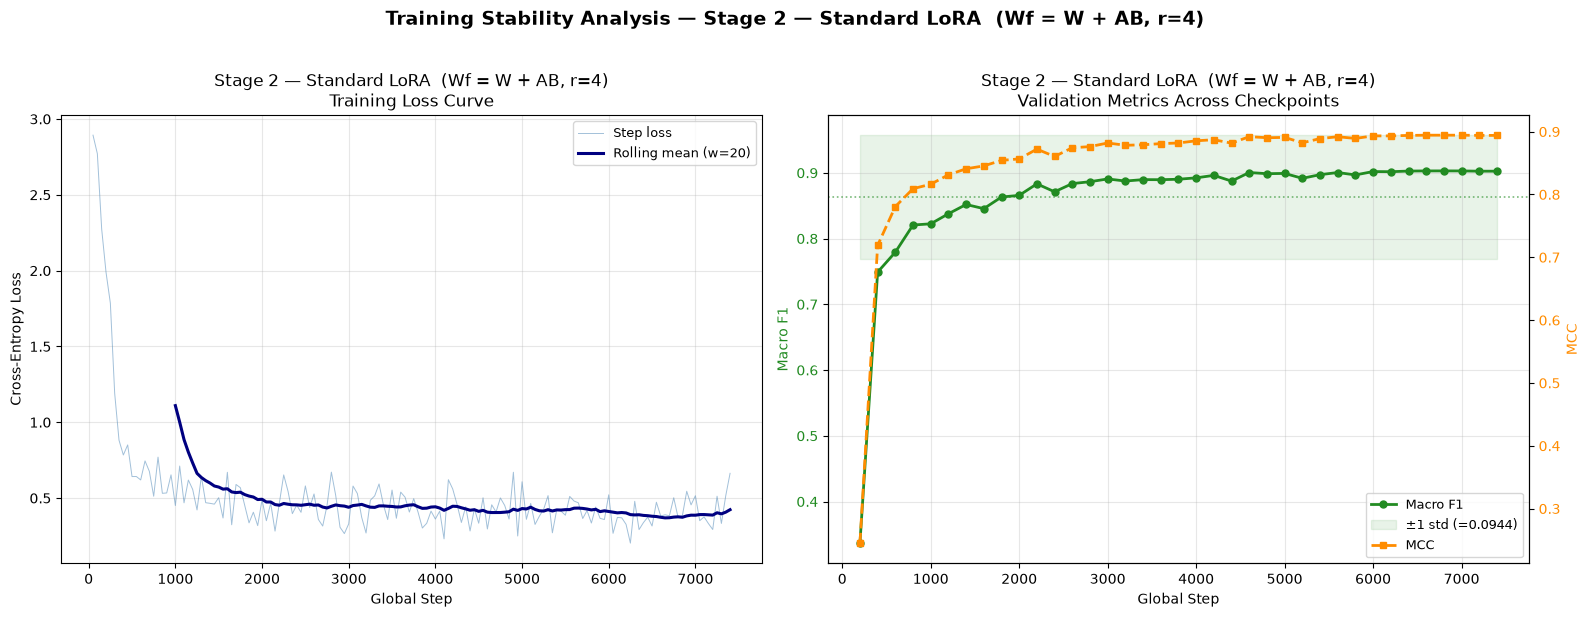

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — StandardLoRA_r4
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9046
  Macro F1          : 0.8934  ← PRIMARY METRIC
  Weighted F1       : 0.9047
  Balanced Accuracy : 0.8936
  MCC               : 0.8852  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7541    0.7388    0.7464      1424
             gender     0.9041    0.8915    0.8978      1788
           religion     0.9543    0.9650    0.9596      1971
          ethnicity     0.9791    0.9834    0.9813      1812
                age     0.9787    0.9651    0.9719      1950
other_cyberbullying     0.7890    0.8181    0.8033      1385

           accuracy                         0.9046     10330
          macro avg     0.8932    0.8936    0.8934    

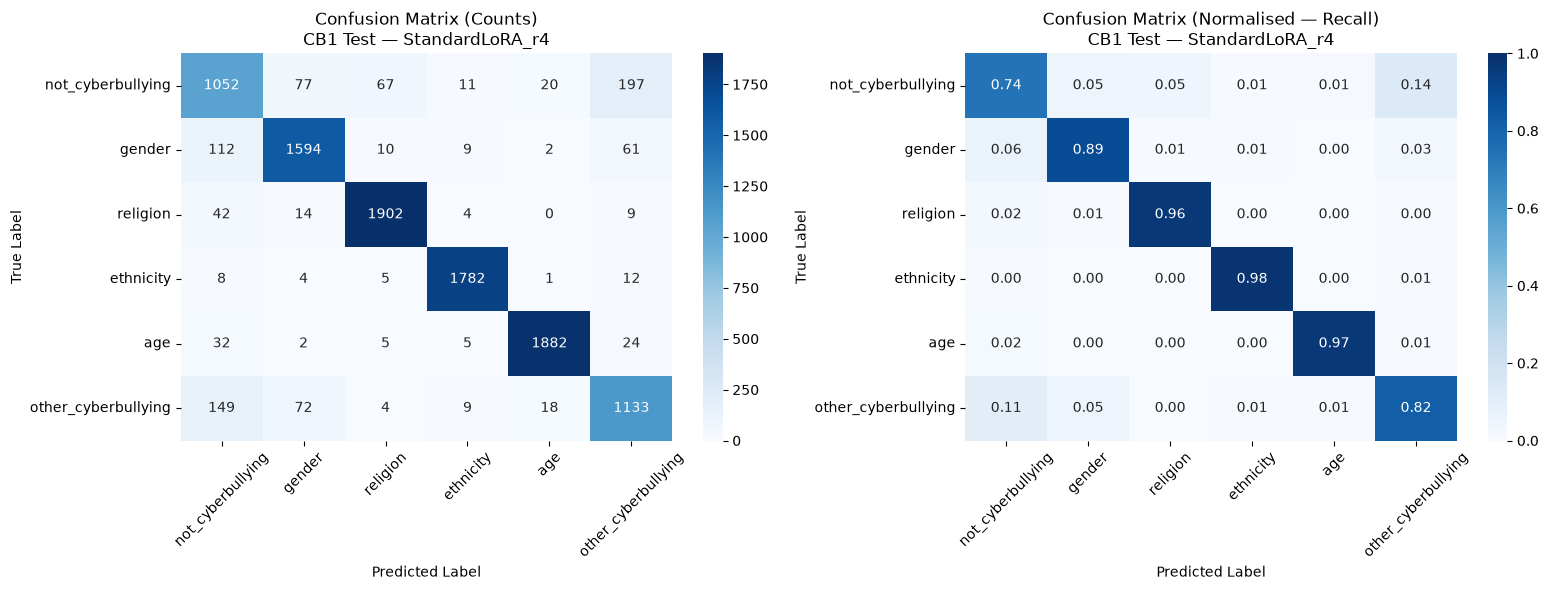


✓ Results saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/StandardLoRA_r4/results_StandardLoRA_r4.csv
   checkpoint written after r=4  |  elapsed 2.94 h

------------------------------------------------------------
  Rank sweep: r = 8   (2 of 4)
------------------------------------------------------------
✓ All random seeds fixed to 42.

  STAGE 2 — STANDARD LoRA  |  StandardLoRA_r8
  Model   : google/gemma-2-9b-it
  Rank r  : 8  |  Alpha: 8  |  Scaling: 1.0
  Formula : Wf = W + AB
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 256,000
   Pad token : "<pad>" (id=0)
[2] Mapping labels and preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

   Trainable: 8,967,168 / 9,250,694,656  (0.097%)
[4] Training — 1 epoch (single-epoch protocol)...


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,1.834700,1.661030,0.433202,0.388695,0.319931
400,0.782400,0.627414,0.793699,0.783855,0.755364
600,0.595600,0.777265,0.823690,0.789293,0.793508
800,0.757200,0.506828,0.852469,0.835604,0.823483
1000,0.452300,0.702143,0.849743,0.828168,0.823014
1200,0.513200,0.545705,0.857619,0.836497,0.831347
1400,0.500200,0.545636,0.876098,0.860895,0.851603
1600,0.671300,0.571758,0.875189,0.854749,0.852593
1800,0.454100,0.550752,0.880339,0.864200,0.856317
2000,0.451700,0.518892,0.883369,0.870921,0.862514


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt


[5] Computing effective rank of Wf = W + AB...
   avg_effective_rank(Wf) = 2815.98
   avg_effective_rank(ΔW) = 8.00  (reference, ≤ r=8)
   LoRA layers measured   = 168

[6] Generating stability report...
   VALIDATION Macro F1 - best: 0.9091 | final: 0.9080   <-- RANK SELECTION USES THIS, NOT THE TEST SCORE
   Loss CV (overall)   : 0.7118520517434905
   Loss std (overall)  : 0.3618748003149637
   Val F1 std          : 0.08620981654075036
   Val MCC std         : 0.0956369592107047
   Composite score     : 0.399031
   Interpretation      : 🔴  Unstable — investigate
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/StandardLoRA_r8/stability_curves.png


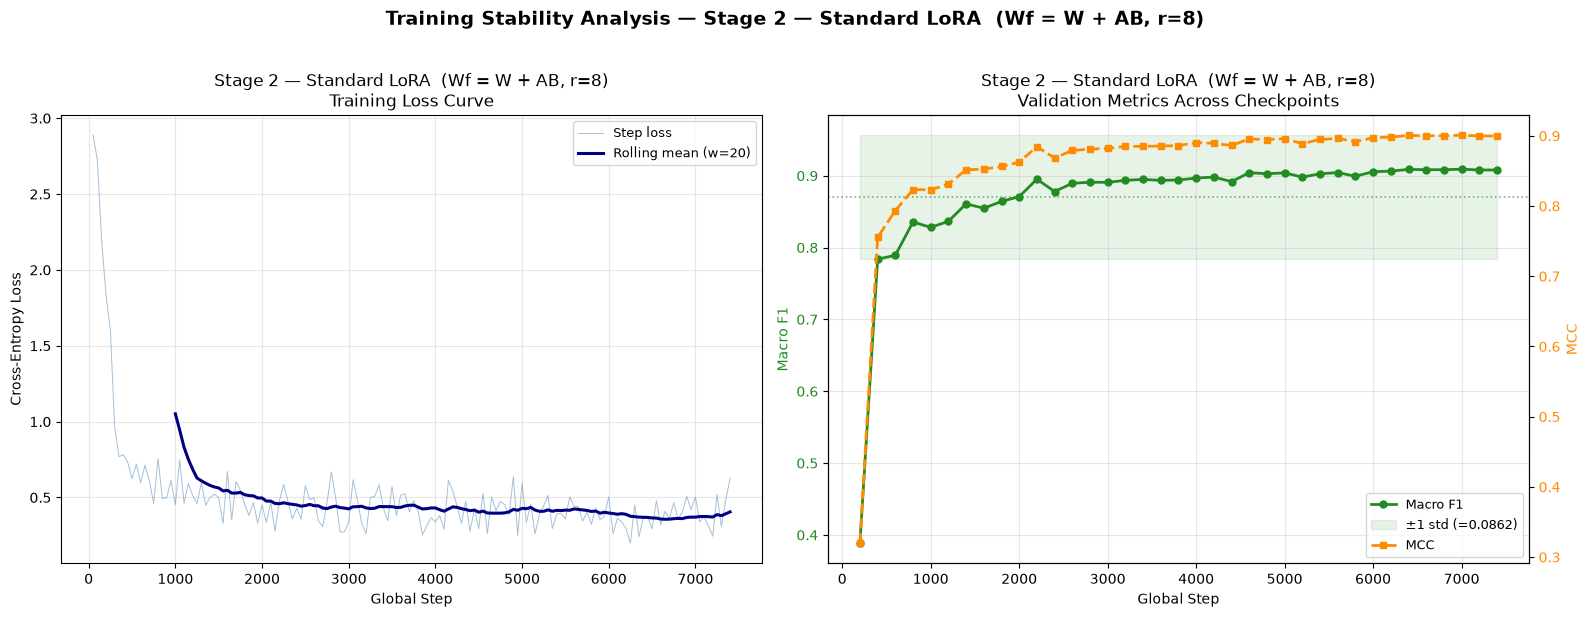

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — StandardLoRA_r8
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9089
  Macro F1          : 0.8982  ← PRIMARY METRIC
  Weighted F1       : 0.9092
  Balanced Accuracy : 0.8985
  MCC               : 0.8903  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7493    0.7577    0.7535      1424
             gender     0.9081    0.8954    0.9017      1788
           religion     0.9596    0.9640    0.9618      1971
          ethnicity     0.9819    0.9862    0.9840      1812
                age     0.9838    0.9667    0.9752      1950
other_cyberbullying     0.8058    0.8209    0.8133      1385

           accuracy                         0.9089     10330
          macro avg     0.8981    0.8985    0.8982    

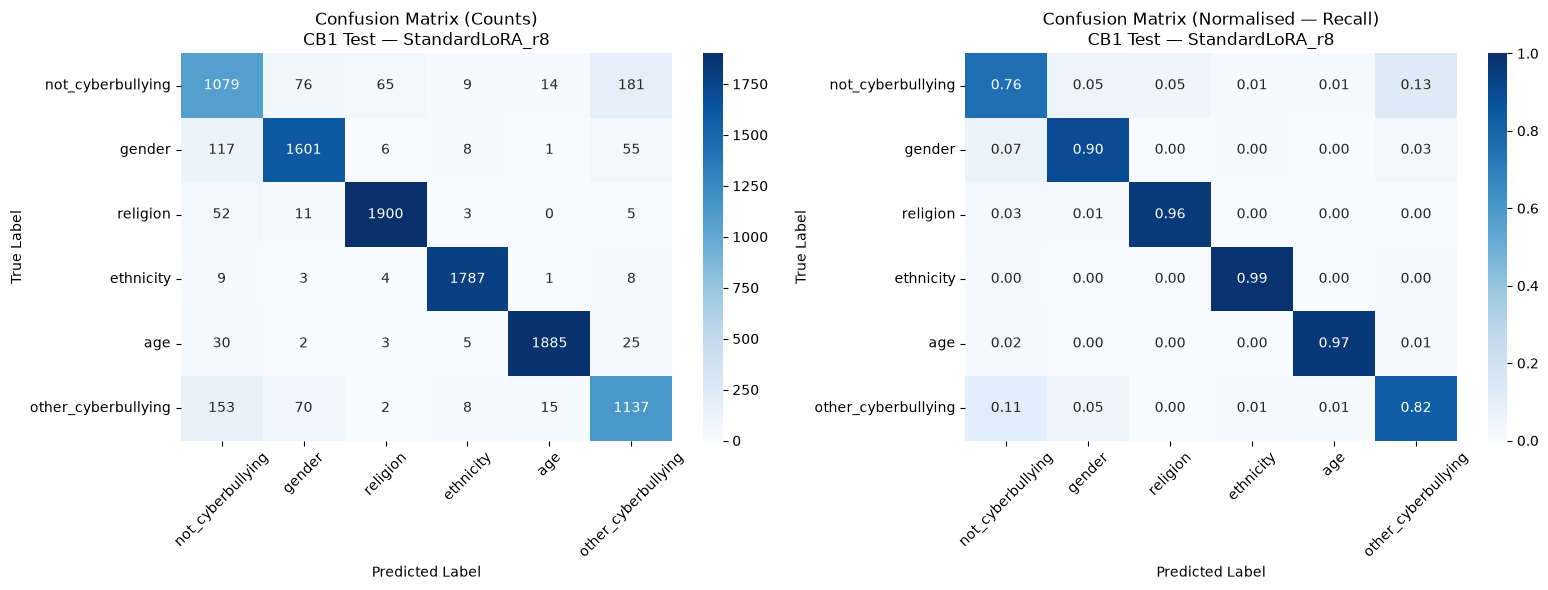


✓ Results saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/StandardLoRA_r8/results_StandardLoRA_r8.csv
   checkpoint written after r=8  |  elapsed 5.95 h

------------------------------------------------------------
  Rank sweep: r = 16   (3 of 4)
------------------------------------------------------------
✓ All random seeds fixed to 42.

  STAGE 2 — STANDARD LoRA  |  StandardLoRA_r16
  Model   : google/gemma-2-9b-it
  Rank r  : 16  |  Alpha: 16  |  Scaling: 1.0
  Formula : Wf = W + AB
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 256,000
   Pad token : "<pad>" (id=0)
[2] Mapping labels and preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,1.601000,1.418944,0.518631,0.467596,0.426222
400,0.811700,0.613034,0.805513,0.790526,0.772168
600,0.608900,0.879221,0.822478,0.782742,0.792343


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,1.601000,1.418944,0.518631,0.467596,0.426222
400,0.811700,0.613034,0.805513,0.790526,0.772168
600,0.608900,0.879221,0.822478,0.782742,0.792343
800,0.742100,0.532019,0.834596,0.818884,0.807428
1000,0.439400,0.681383,0.852469,0.832221,0.826890
1200,0.556900,0.547130,0.860042,0.839160,0.835084
1400,0.541500,0.543774,0.873978,0.858929,0.849530
1600,0.697500,0.548016,0.878219,0.857202,0.856208
1800,0.476900,0.602010,0.873372,0.856453,0.848078
2000,0.457700,0.519728,0.883369,0.870359,0.862592


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
#  RANK SWEEP  r in {4, 8, 16, 32}  -- SELECTED ON VALIDATION
#
#
#  Rank selection: the rank is chosen by validation Macro F1. Test scores are
#  computed and printed for every rank, but they play NO part in the choice.
#  The submitted paper chose the Stage 2 rank on the test score.
#
#  Runtime: about 14 hours for four runs (measured 3.49 h/run on A100).
#  Each rank writes its CSV to Drive as soon as it finishes, so a dropped
#  session costs one run rather than four.
# ═════════════════════════════════════════════════════════════════════════════
import time, json as _json

all_rank_results = {}
_t0 = time.time()

for r in RANK_SWEEP:
    print(f'\n{"-"*60}')
    print(f'  Rank sweep: r = {r}   ({RANK_SWEEP.index(r)+1} of {len(RANK_SWEEP)})')
    print(f'{"-"*60}')
    res = run_standard_lora(
        train_df  = train_df,
        val_df    = val_df,
        test_df   = test_df,
        lora_rank = r,
        run_label = f'StandardLoRA_r{r}'
    )
    all_rank_results[r] = res

    # checkpoint after every rank so nothing is lost
    _snap = pd.DataFrame([{
        'rank': rr,
        'trainable_params': all_rank_results[rr]['trainable_params'],
        'val_f1_best':      all_rank_results[rr]['val_f1_best'],
        'test_macro_f1':    all_rank_results[rr]['macro_f1'],
        'test_mcc':         all_rank_results[rr]['mcc'],
        'eff_rank_Wf':      all_rank_results[rr]['avg_eff_rank_Wf'],
    } for rr in sorted(all_rank_results)])
    _snap.to_csv(os.path.join(OUTPUT_DIR, 'stage2_cb1_rank_sweep_VALIDATION_SELECTED.csv'), index=False)
    print(f'   checkpoint written after r={r}  |  elapsed {(time.time()-_t0)/3600:.2f} h')

# ── selection, on validation only ────────────────────────────────────────────
best_r = max(all_rank_results, key=lambda k: all_rank_results[k]['val_f1_best'])
best   = all_rank_results[best_r]

print('\n' + '='*92)
print('STAGE 2 - CB1 - Gemma-2-9B - ADDITIVE LoRA - RANK SELECTED ON VALIDATION')
print('='*92)
print(f'{"r":>4} | {"trainable":>12} | {"VAL Macro F1":>13} | {"TEST Macro F1":>14} | {"MCC":>7} | selected')
for r in sorted(all_rank_results):
    a = all_rank_results[r]
    print(f'{r:>4} | {a["trainable_params"]:>12,} | {a["val_f1_best"]:>13.4f} | '
          f'{a["macro_f1"]:>14.4f} | {a["mcc"]:>7.4f} | {"<== SELECTED" if r==best_r else ""}')
print('='*92)
print(f'Selected r={best_r} on validation ({best["val_f1_best"]:.4f}). '
      f'Reported test Macro F1 = {best["macro_f1"]:.4f}, {best["trainable_params"]:,} trainable parameters.')
print('Test scores at non-selected ranks are shown for transparency and played no part in selection.')

# ── the two numbers the revision is waiting on ───────────────────────────────
S4_R8_PARAMS = 18_945_024   # Stage 4, CB1, r=8, validation-selected
S4_R8_F1     = 0.9044
S4_R4_PARAMS = 9_483_264    # Stage 4, CB1, r=4
S4_R4_F1     = 0.9064

print('\n' + '='*92)
print('FOR SECTION 5.1 - THE PARAMETER-EFFICIENCY CLAIM (tracker item PE)')
print('='*92)
ratio = best['trainable_params'] / S4_R8_PARAMS
print(f'  Stage 2 selected : r={best_r}, {best["trainable_params"]:>11,} params, test F1 {best["macro_f1"]:.4f}')
print(f'  Stage 4 selected : r=8,  {S4_R8_PARAMS:>11,} params, test F1 {S4_R8_F1:.4f}')
print(f'  Ratio            : {ratio:.2f}x  (paper claimed 3.8x)')
print(f'  Accuracy delta   : {S4_R8_F1 - best["macro_f1"]:+.4f} in favour of Stage 4')
if ratio < 1:
    print('  >> Stage 4 uses MORE parameters than Stage 2 at the selected ranks.')
    print('     The efficiency claim must be dropped. Rest the contribution on')
    print('     accuracy and on the rank result instead. Report this honestly.')
else:
    print(f'  >> The efficiency claim survives at {ratio:.2f}x, not 3.8x. Restate it with this number.')

print('\n  MATCHED-PARAMETER COMPARISON (tracker items 2A and 5c)')
for r in sorted(all_rank_results):
    a = all_rank_results[r]
    print(f'    Stage 2 r={r:<3} {a["trainable_params"]:>11,} params -> F1 {a["macro_f1"]:.4f}')
    if abs(a['trainable_params'] - S4_R4_PARAMS) / S4_R4_PARAMS < 0.20:
        print(f'      ^ closest match to Stage 4 r=4 ({S4_R4_PARAMS:,} params, F1 {S4_R4_F1:.4f}), '
              f'delta {S4_R4_F1 - a["macro_f1"]:+.4f}')
    if abs(a['trainable_params'] - S4_R8_PARAMS) / S4_R8_PARAMS < 0.20:
        print(f'      ^ closest match to Stage 4 r=8 ({S4_R8_PARAMS:,} params, F1 {S4_R8_F1:.4f}), '
              f'delta {S4_R8_F1 - a["macro_f1"]:+.4f}')

summary_df = pd.DataFrame([{
    'Rank (r)':         all_rank_results[r]['lora_rank'],
    'Trainable Params': all_rank_results[r]['trainable_params'],
    'VAL Macro F1':     round(all_rank_results[r]['val_f1_best'], 4),
    'Test Macro F1':    round(all_rank_results[r]['macro_f1'],    4),
    'Test MCC':         round(all_rank_results[r]['mcc'],         4),
    'Accuracy':         round(all_rank_results[r]['accuracy'],    4),
    'Eff. Rank (Wf)':   round(all_rank_results[r]['avg_eff_rank_Wf'], 2),
    'Eff. Rank (dW)':   round(all_rank_results[r]['avg_eff_rank_dW'], 2),
    'Stability Score':  round(all_rank_results[r]['stability_score'], 6),
    'Selected':         'YES' if r == best_r else '',
} for r in sorted(all_rank_results)])

summary_path = os.path.join(OUTPUT_DIR, 'stage2_cb1_rank_sweep_VALIDATION_SELECTED.csv')
summary_df.to_csv(summary_path, index=False)
print(f'\nSaved -> {summary_path}')
print(summary_df.to_string(index=False))
print(f'\nTotal elapsed: {(time.time()-_t0)/3600:.2f} h')
print(f'>> Selected r={best_r} for the Stage 2 multi-seed runs.')


valid, from the patched runs : [4, 8]
skipped as stale June files  : [16, 32]
still to run                 : [16, 32]

------------------------------------------------------------
  Resuming: r = 16
------------------------------------------------------------
✓ All random seeds fixed to 42.

  STAGE 2 — STANDARD LoRA  |  StandardLoRA_r16
  Model   : google/gemma-2-9b-it
  Rank r  : 16  |  Alpha: 16  |  Scaling: 1.0
  Formula : Wf = W + AB
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...


tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

   Vocab size: 256,000
   Pad token : "<pad>" (id=0)
[2] Mapping labels and preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

...

   Trainable: 17,912,832 / 9,259,640,320  (0.193%)
[4] Training — 1 epoch (single-epoch protocol)...


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,1.600400,1.419078,0.519540,0.469176,0.427305
400,0.811200,0.613646,0.804302,0.788796,0.770508
600,0.596900,0.867481,0.822175,0.784269,0.792345
800,0.753500,0.494042,0.851560,0.837689,0.824211
1000,0.439100,0.685338,0.850651,0.829991,0.824855
1200,0.551300,0.528966,0.864586,0.846310,0.839366
1400,0.521100,0.577518,0.871251,0.855271,0.846096
1600,0.715600,0.567274,0.879733,0.858365,0.857862
1800,0.472300,0.553911,0.878522,0.862691,0.854117
2000,0.462500,0.519743,0.888216,0.875656,0.867252


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt


[5] Computing effective rank of Wf = W + AB...
   avg_effective_rank(Wf) = 2815.98
   avg_effective_rank(ΔW) = 16.00  (reference, ≤ r=16)
   LoRA layers measured   = 168

[6] Generating stability report...
   VALIDATION Macro F1 - best: 0.9090 | final: 0.9073   <-- RANK SELECTION USES THIS, NOT THE TEST SCORE
   Loss CV (overall)   : 0.6911285437469727
   Loss std (overall)  : 0.3427381165040562
   Val F1 std          : 0.0740997075697876
   Val MCC std         : 0.07897066703804503
   Composite score     : 0.382614
   Interpretation      : 🔴  Unstable — investigate
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/StandardLoRA_r16/stability_curves.png


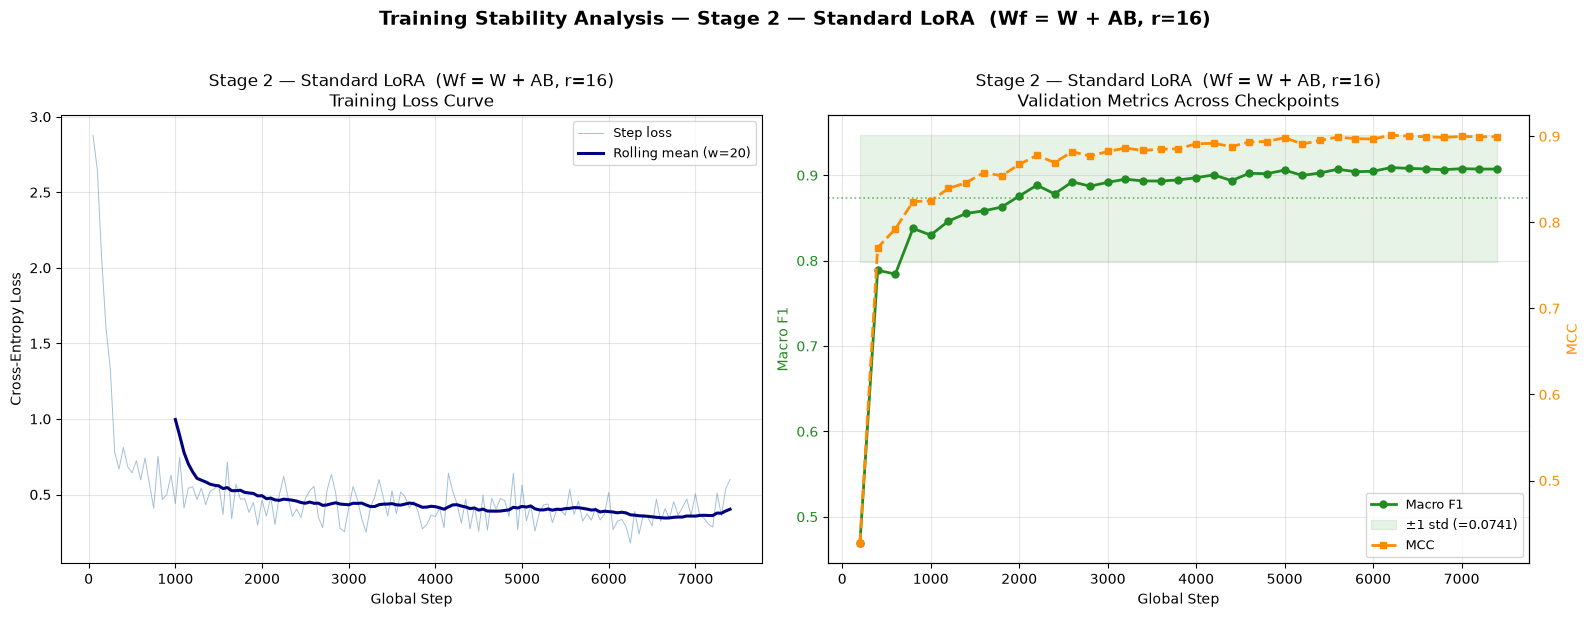

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — StandardLoRA_r16
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9105
  Macro F1          : 0.9001  ← PRIMARY METRIC
  Weighted F1       : 0.9108
  Balanced Accuracy : 0.9004
  MCC               : 0.8922  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7561    0.7619    0.7590      1424
             gender     0.9102    0.8954    0.9027      1788
           religion     0.9588    0.9670    0.9629      1971
          ethnicity     0.9808    0.9873    0.9840      1812
                age     0.9868    0.9621    0.9743      1950
other_cyberbullying     0.8067    0.8289    0.8177      1385

           accuracy                         0.9105     10330
          macro avg     0.8999    0.9004    0.9001   

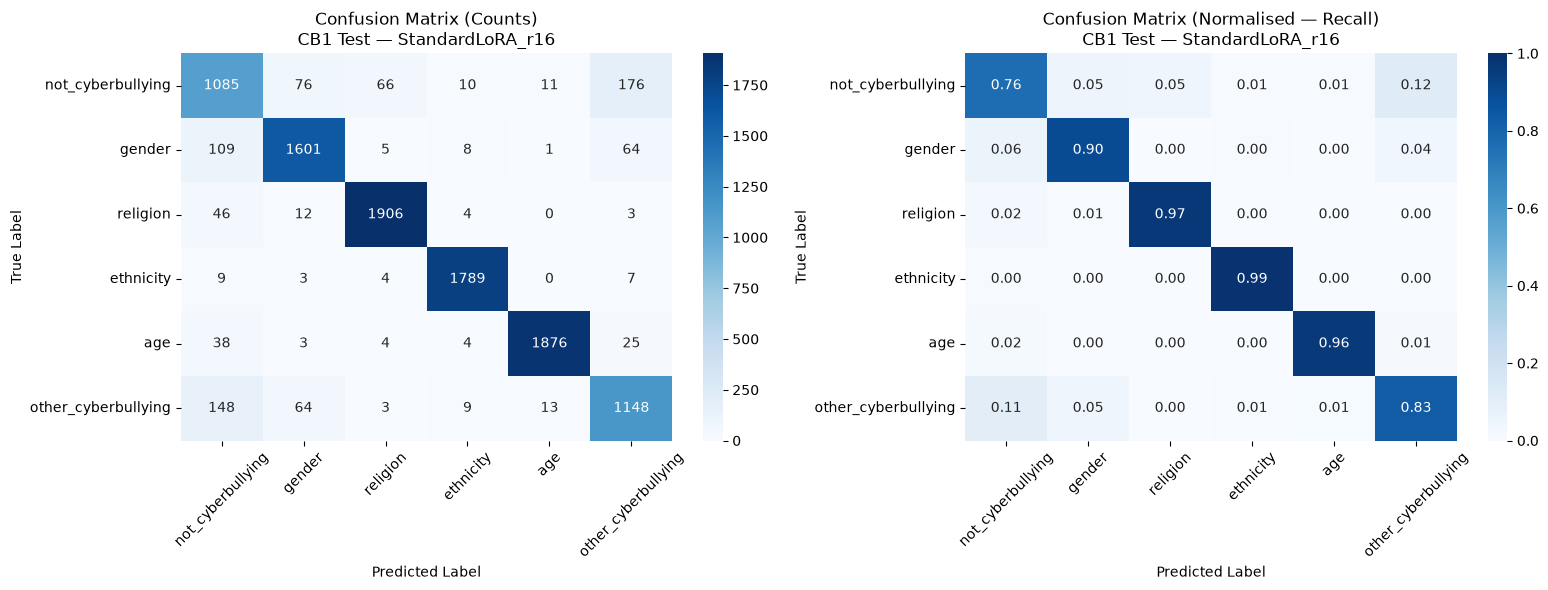


✓ Results saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/StandardLoRA_r16/results_StandardLoRA_r16.csv
   checkpoint written after r=16  |  elapsed 2.93 h

------------------------------------------------------------
  Resuming: r = 32
------------------------------------------------------------
✓ All random seeds fixed to 42.

  STAGE 2 — STANDARD LoRA  |  StandardLoRA_r32
  Model   : google/gemma-2-9b-it
  Rank r  : 32  |  Alpha: 32  |  Scaling: 1.0
  Formula : Wf = W + AB
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 256,000
   Pad token : "<pad>" (id=0)
[2] Mapping labels and preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

   Trainable: 35,804,160 / 9,277,531,648  (0.386%)
[4] Training — 1 epoch (single-epoch protocol)...


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,1.294800,1.079470,0.628294,0.588810,0.557486
400,0.809600,0.566283,0.820055,0.804447,0.787242
600,0.626000,0.831822,0.823993,0.777929,0.795404
800,0.789700,0.540337,0.840351,0.817759,0.814638
1000,0.421400,0.703156,0.856104,0.834708,0.831514
1200,0.594700,0.556106,0.858831,0.837256,0.834328
1400,0.561800,0.546185,0.869131,0.850713,0.844290
1600,0.733000,0.509204,0.885489,0.867096,0.863858
1800,0.513600,0.526204,0.882460,0.867987,0.858772
2000,0.470600,0.518280,0.894274,0.882162,0.874732


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt


[5] Computing effective rank of Wf = W + AB...
   avg_effective_rank(Wf) = 2815.98
   avg_effective_rank(ΔW) = 32.00  (reference, ≤ r=32)
   LoRA layers measured   = 168

[6] Generating stability report...
   VALIDATION Macro F1 - best: 0.9139 | final: 0.9139   <-- RANK SELECTION USES THIS, NOT THE TEST SCORE
   Loss CV (overall)   : 0.6662848390260302
   Loss std (overall)  : 0.3239954091350888
   Val F1 std          : 0.05837195828005769
   Val MCC std         : 0.06067627314369474
   Composite score     : 0.362328
   Interpretation      : 🔴  Unstable — investigate
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/StandardLoRA_r32/stability_curves.png


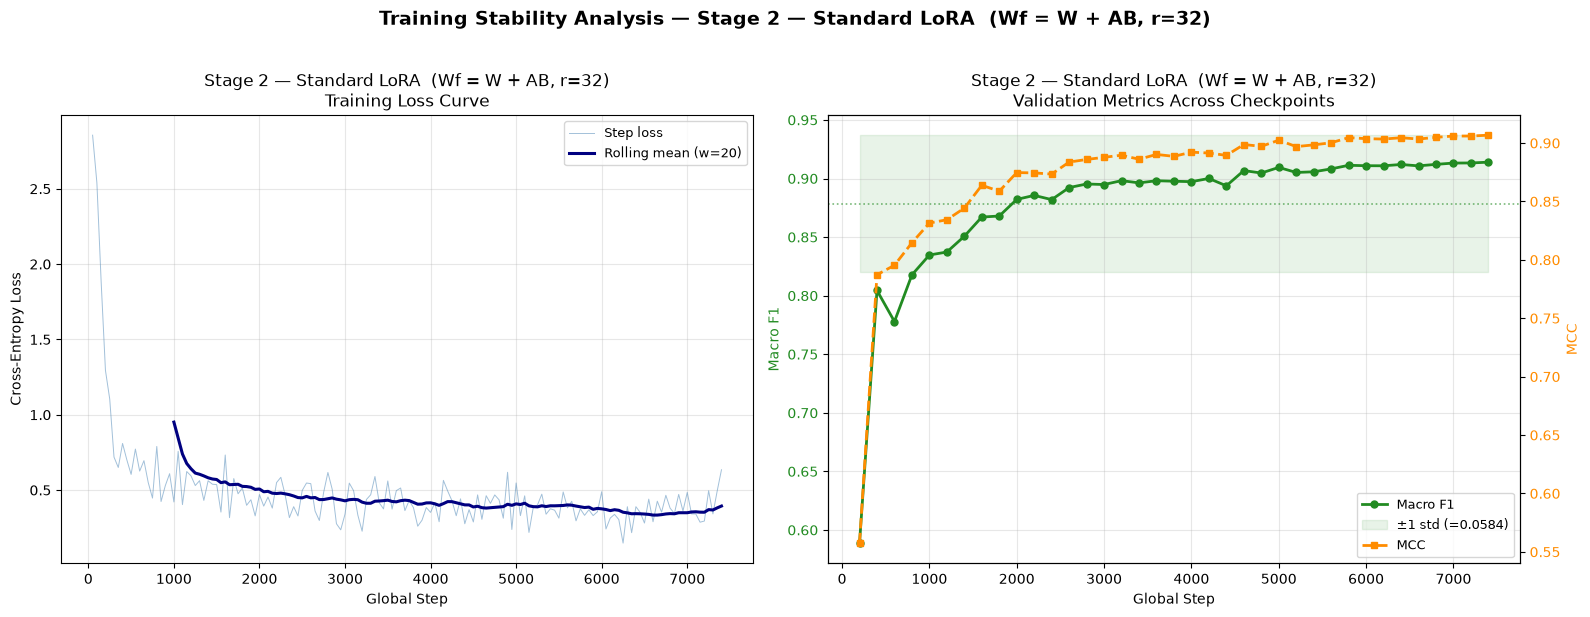

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — StandardLoRA_r32
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9140
  Macro F1          : 0.9035  ← PRIMARY METRIC
  Weighted F1       : 0.9141
  Balanced Accuracy : 0.9039
  MCC               : 0.8965  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7768    0.7528    0.7646      1424
             gender     0.9140    0.9032    0.9086      1788
           religion     0.9608    0.9706    0.9657      1971
          ethnicity     0.9851    0.9873    0.9862      1812
                age     0.9859    0.9677    0.9767      1950
other_cyberbullying     0.7975    0.8419    0.8191      1385

           accuracy                         0.9140     10330
          macro avg     0.9034    0.9039    0.9035   

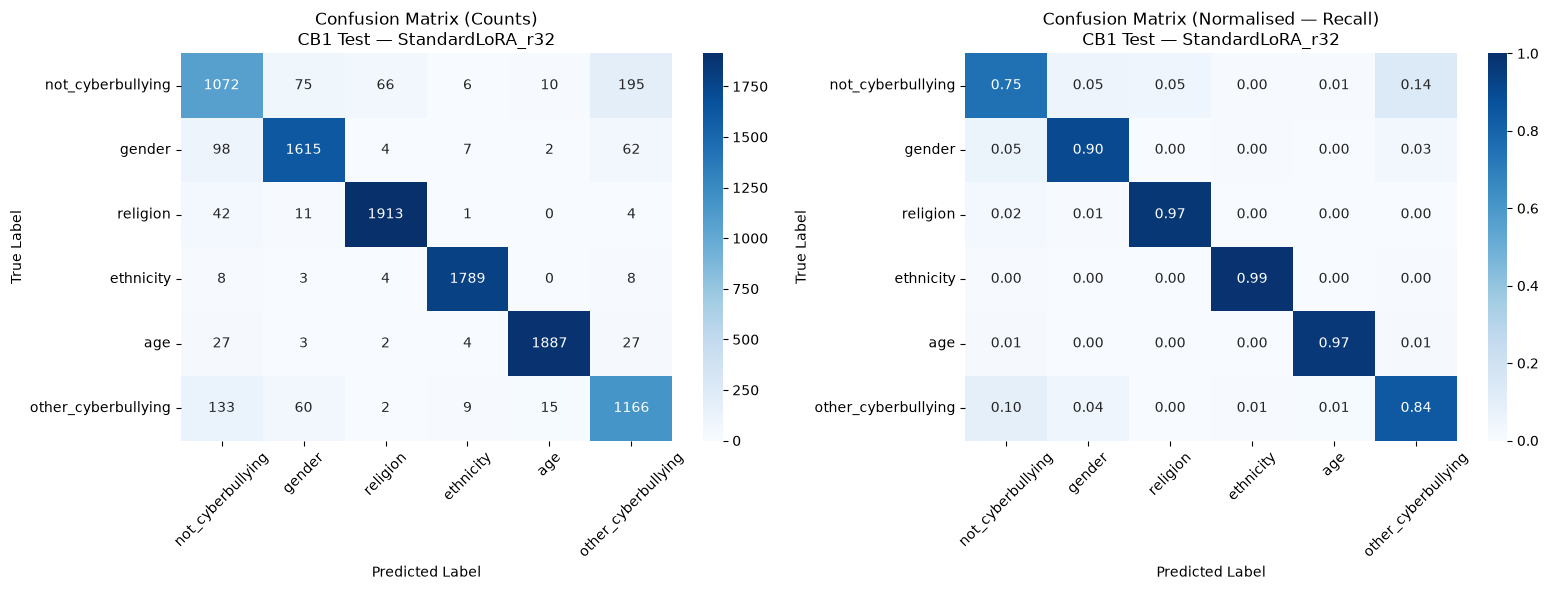


✓ Results saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/StandardLoRA_r32/results_StandardLoRA_r32.csv
   checkpoint written after r=32  |  elapsed 5.96 h

STAGE 2 - CB1 - Gemma-2-9B - ADDITIVE LoRA - RANK SELECTED ON VALIDATION
   r |    trainable |  VAL Macro F1 |  TEST Macro F1 | selected
   4 |    4,494,336 |        0.9029 |         0.8934 | 
   8 |    8,967,168 |        0.9091 |         0.8982 | 
  16 |   17,912,832 |        0.9090 |         0.9001 | 
  32 |   35,804,160 |        0.9139 |         0.9035 | <== SELECTED

Stage 2 selected r=32: 35,804,160 params, test 0.9035
Stage 4 selected r=8 : 18,945,024 params, test 0.9044
Efficiency ratio     : 1.89x   (paper claimed 3.8x)
Accuracy delta       : +0.0009 in favour of Stage 4


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
#  RESUME v2. Only accepts result files from the Note runs, identified by
#  the presence of val_f1_best. June files have no validation column and are
#  skipped, so old and new results can never be mixed.
# ═══════════════════════════════════════════════════════════════════════════
import glob, time, os, math

all_rank_results, stale = {}, []
for p in sorted(glob.glob(os.path.join(OUTPUT_DIR, 'StandardLoRA_r*', 'results_*.csv'))):
    row = pd.read_csv(p).iloc[0].to_dict()
    v = row.get('val_f1_best', None)
    if v is None or (isinstance(v, float) and math.isnan(v)):
        stale.append(int(row['lora_rank'])); continue
    all_rank_results[int(row['lora_rank'])] = row

print('valid, from the patched runs :', sorted(all_rank_results))
print('skipped as stale June files  :', sorted(stale))
missing = [r for r in RANK_SWEEP if r not in all_rank_results]
print('still to run                 :', missing)

_t0 = time.time()
for r in missing:
    print(f'\n{"-"*60}\n  Resuming: r = {r}\n{"-"*60}')
    all_rank_results[r] = run_standard_lora(
        train_df=train_df, val_df=val_df, test_df=test_df,
        lora_rank=r, run_label=f'StandardLoRA_r{r}')
    pd.DataFrame([{
        'rank': rr,
        'trainable_params': all_rank_results[rr]['trainable_params'],
        'val_f1_best':      all_rank_results[rr]['val_f1_best'],
        'test_macro_f1':    all_rank_results[rr]['macro_f1'],
        'test_mcc':         all_rank_results[rr]['mcc'],
        'eff_rank_Wf':      all_rank_results[rr]['avg_eff_rank_Wf'],
    } for rr in sorted(all_rank_results)]).to_csv(
        os.path.join(OUTPUT_DIR, 'stage2_cb1_rank_sweep_VALIDATION_SELECTED.csv'), index=False)
    print(f'   checkpoint written after r={r}  |  elapsed {(time.time()-_t0)/3600:.2f} h')

best_r = max(all_rank_results, key=lambda k: all_rank_results[k]['val_f1_best'])
best   = all_rank_results[best_r]

print('\n' + '='*92)
print('STAGE 2 - CB1 - Gemma-2-9B - ADDITIVE LoRA - RANK SELECTED ON VALIDATION')
print('='*92)
print(f'{"r":>4} | {"trainable":>12} | {"VAL Macro F1":>13} | {"TEST Macro F1":>14} | selected')
for r in sorted(all_rank_results):
    a = all_rank_results[r]
    print(f'{r:>4} | {a["trainable_params"]:>12,.0f} | {a["val_f1_best"]:>13.4f} | '
          f'{a["macro_f1"]:>14.4f} | {"<== SELECTED" if r==best_r else ""}')

S4_R8_PARAMS, S4_R8_F1 = 18_945_024, 0.9044
ratio = best['trainable_params'] / S4_R8_PARAMS
print(f'\nStage 2 selected r={best_r}: {best["trainable_params"]:,.0f} params, test {best["macro_f1"]:.4f}')
print(f'Stage 4 selected r=8 : {S4_R8_PARAMS:,} params, test {S4_R8_F1:.4f}')
print(f'Efficiency ratio     : {ratio:.2f}x   (paper claimed 3.8x)')
print(f'Accuracy delta       : {S4_R8_F1 - best["macro_f1"]:+.4f} in favour of Stage 4')

## Recovery cell (only if the session dropped)


In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
#  RECOVERY - run this ONLY if the session dropped part-way through the sweep.
#  It rebuilds all_rank_results from the per-run CSVs already on Drive, so only rerun the ranks that are actually missing.
# ═════════════════════════════════════════════════════════════════════════════
import glob
all_rank_results = {}
for p in sorted(glob.glob(os.path.join(OUTPUT_DIR, 'StandardLoRA_r*', 'results_*.csv'))):
    row = pd.read_csv(p).iloc[0].to_dict()
    all_rank_results[int(row['lora_rank'])] = row
print('recovered ranks:', sorted(all_rank_results))
missing = [r for r in RANK_SWEEP if r not in all_rank_results]
print('still missing :', missing)
if missing:
    print(f'>> Set RANK_SWEEP = {missing} and re-run the sweep cell, then run it again with the full list.')
else:
    print('>> All four ranks present. Skip the training loop and run the selection block only.')


---
## Step 14: Cross-Stage Stability Comparison (Run After All Stages Complete)

In [12]:
# ═══════════════════════════════════════════════════════════════════════════
#  Step 14 — Note. Reads the validation-selected run from the sweep
#  instead of results_r16, which no longer exists (Step 12 is disabled).
# ═══════════════════════════════════════════════════════════════════════════
best   = all_rank_results[best_r]
has_cb = isinstance(best, dict) and 'stability_cb' in best

print(f'Stage 2 stability report (validation-selected r={best_r}):')
if has_cb:
    rep = best['stability_cb'].get_stability_report()
    for k in ['loss_cv_overall','loss_std_overall','val_f1_std','val_mcc_std','stability_score']:
        print(f'   {k:<20} : {rep.get(k, "N/A")}')
else:
    print('   (rebuilt from CSV, callback object not available)')
    print(f'   stability_score      : {best.get("stability_score","N/A")}')

print('\n' + '='*70)
print('  STAGE 2 COMPLETE — STANDARD (ADDITIVE) LoRA')
print('  Formula : Wf = W + AB')
print('  Model   : google/gemma-2-9b-it')
print('  Dataset : CB1, 6-class')
print('  Split   : 75/25 stratified, seed 42')
print('='*70)
print(f'\n--- SELECTED ON VALIDATION: r={best_r} ---')
print(f'  Validation Macro F1 : {best["val_f1_best"]:.4f}   <- SELECTION METRIC')
print(f'  Test Macro F1       : {best["macro_f1"]:.4f}   <- reported, not used to select')
print(f'  MCC                 : {best["mcc"]:.4f}')
print(f'  Accuracy            : {best["accuracy"]:.4f}')
print(f'  Trainable params    : {best["trainable_params"]:,}')
print(f'  Eff. rank (Wf)      : {best["avg_eff_rank_Wf"]:.2f}')

print('\n--- ALL RANKS (transparency; selection used validation only) ---')
for r in sorted(all_rank_results):
    a = all_rank_results[r]
    mark = '  <-- selected' if r == best_r else ''
    print(f'  r={r:<3} val={a["val_f1_best"]:.4f} | test={a["macro_f1"]:.4f} | '
          f'params={a["trainable_params"]:>11,}{mark}')

print('   Those decide whether the 3.8x efficiency claim survives.')

Stage 2 stability report (validation-selected r=32):
   loss_cv_overall      : 0.6662848390260302
   loss_std_overall     : 0.3239954091350888
   val_f1_std           : 0.05837195828005769
   val_mcc_std          : 0.06067627314369474
   stability_score      : 0.362328

  STAGE 2 COMPLETE — STANDARD (ADDITIVE) LoRA
  Formula : Wf = W + AB
  Model   : google/gemma-2-9b-it
  Dataset : CB1, 6-class
  Split   : 75/25 stratified, seed 42

--- SELECTED ON VALIDATION: r=32 ---
  Validation Macro F1 : 0.9139   <- SELECTION METRIC
  Test Macro F1       : 0.9035   <- reported, not used to select
  MCC                 : 0.8965
  Accuracy            : 0.9140
  Trainable params    : 35,804,160
  Eff. rank (Wf)      : 2815.98

--- ALL RANKS (transparency; selection used validation only) ---
  r=4   val=0.9029 | test=0.8934 | params=  4,494,336
  r=8   val=0.9091 | test=0.8982 | params=  8,967,168
  r=16  val=0.9090 | test=0.9001 | params= 17,912,832
  r=32  val=0.9139 | test=0.9035 | params= 35,804,